# S7 · Student exercise — reconstruct a PDF table

**Your task:** import the licensing table on **page 1** of `docs/column_separators.pdf` into a usable pandas DataFrame. One DataFrame row must correspond to **one licence entry on the printed page**. Keep the licence number and ZIP code as text. You do not need to analyse the licences or work on page 2.

You may use AI and the Camelot documentation. Your conclusions must be supported by inspection of the PDF and a few source rows. Submit the notebook and your final DataFrame (or an exported CSV).

In [1]:
from pathlib import Path
import camelot
import pandas as pd

# Locate docs/ whether the notebook runs in the course folder or notebooks/.
here = Path.cwd()
ROOT = next((p for p in [here, here.parent, here / "S7_course_material_REVISED"]
             if (p / "docs" / "column_separators.pdf").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Open S7_course_material_REVISED or its notebooks/ folder.")
SOURCE = ROOT / "docs" / "column_separators.pdf"
print("Source:", SOURCE.resolve())

Source: /Users/guillaumeleorat/Projects/Teaching/AlbertSchool/Advanced_EDA_DataCollection/Students/Session7/docs/column_separators.pdf


## 1 · Look at the original page

Open page 1 of the PDF in a viewer. Locate the table, count its intended columns and observe its headings, report title, repeated licence entries and text wrapped onto extra lines. Note what a correct *record* looks like.

Pages in source: 2


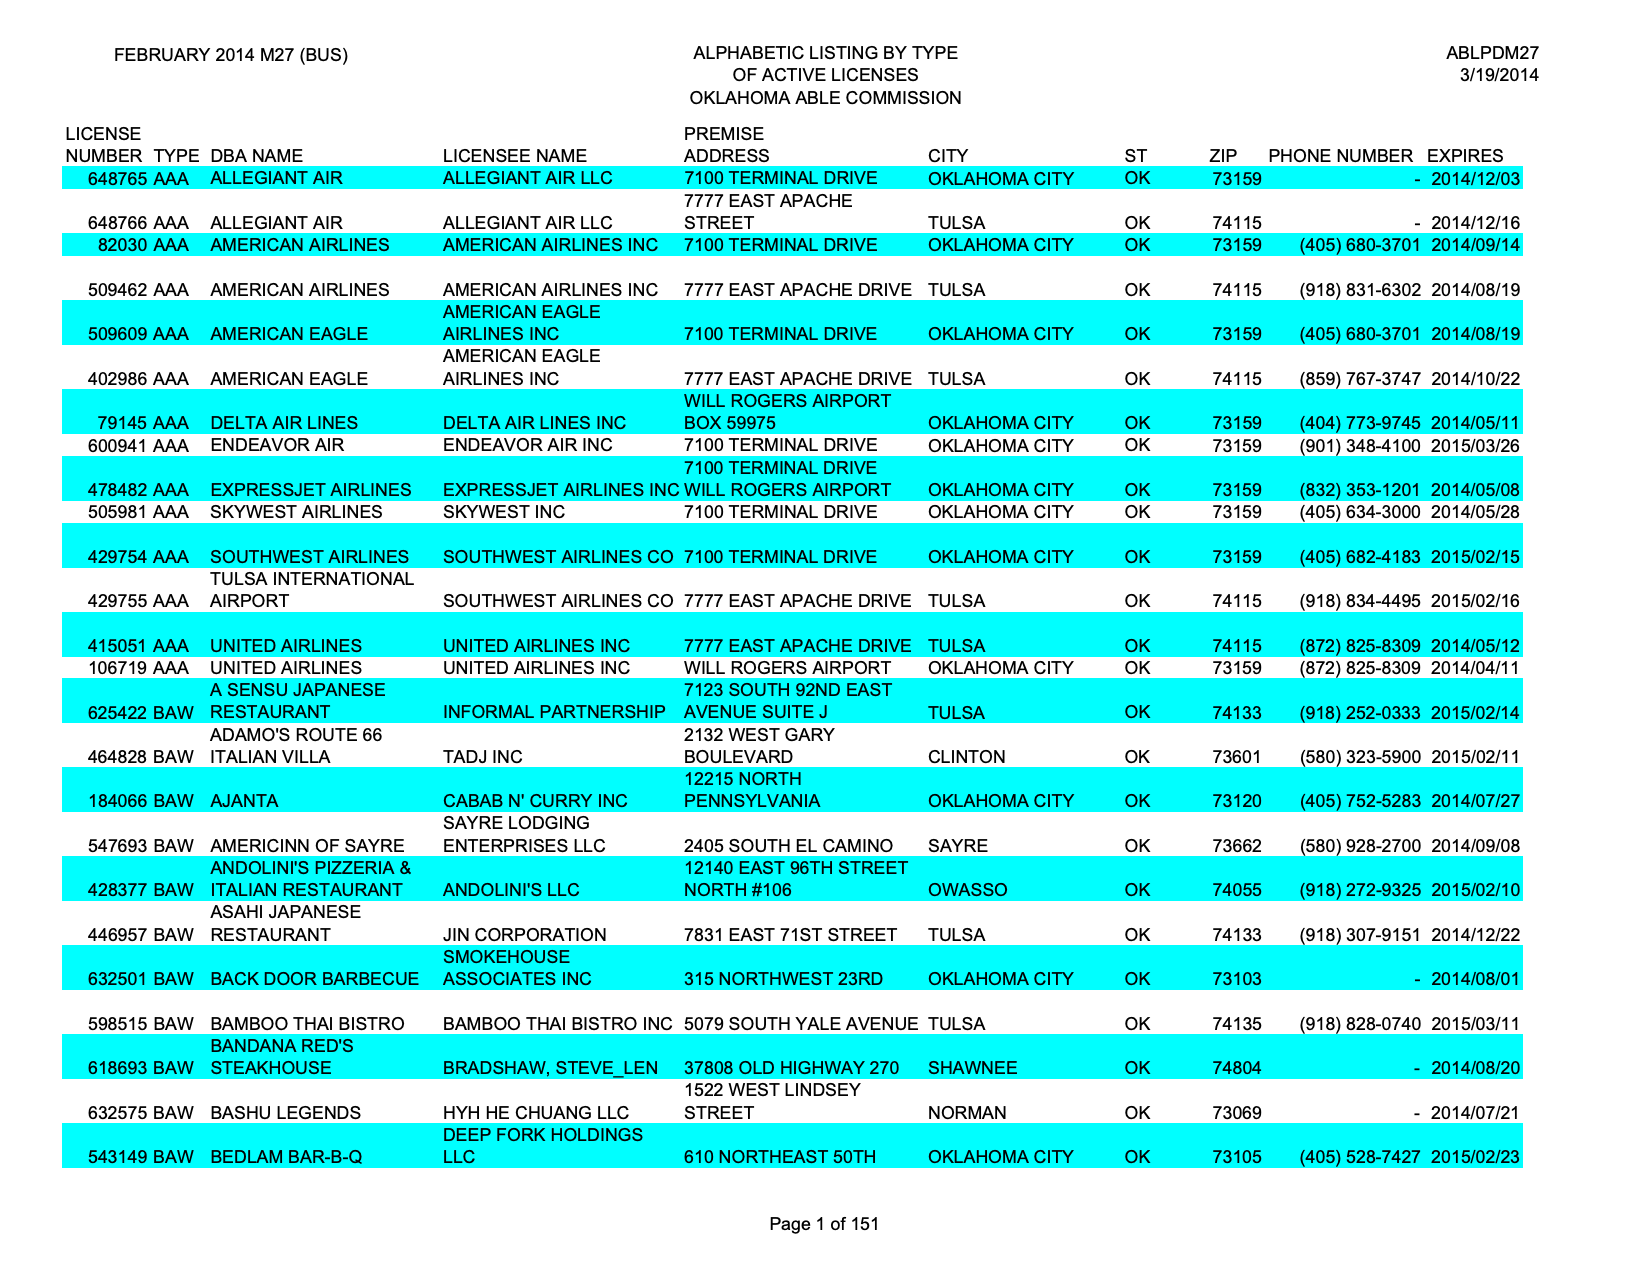

In [5]:
import pdfplumber
from IPython.display import display

with pdfplumber.open(SOURCE) as document:
    print("Pages in source:", len(document.pages))

    # Select page 1 and display its original layout.
    first_page = document.pages[0]
    image = first_page.to_image(resolution=150)
    display(image.original)

## 2 · Try a first extraction

Test Camelot with `flavor="lattice"` and `flavor="stream"` on `pages="1"`. Inspect the number of candidates, each shape, and a few raw rows. Which result comes closer to the printed page? Explain *one specific mismatch* you can see.

In [6]:
# Extract tables using visible grid lines.
lattice = camelot.read_pdf(str(SOURCE), pages="1", flavor="lattice")

print("Lattice candidates:", len(lattice))
for candidate in lattice:
    print("shape:", candidate.df.shape, "report:", candidate.parsing_report)
    display(candidate.df.head(7))

Lattice candidates: 0


In [7]:
# Extract tables using text alignment.
stream = camelot.read_pdf(str(SOURCE), pages="1", flavor="stream")

print("Stream candidates:", len(stream))
for candidate in stream:
    print("shape:", candidate.df.shape, "report:", candidate.parsing_report)
    display(candidate.df.head(7))

Stream candidates: 1
shape: (46, 6) report: {'accuracy': 97.63, 'whitespace': 35.87, 'order': 1, 'page': 1}


,0,1,2,3,4,5
0,FEBRUARY 2014 M27 (BUS),,,,,
1,,OF ACTIVE LICENSES,,,,3/19/2014
2,,OKLAHOMA ABLE COMMISSION,,,,
3,LICENSE,PREMISE,,,,
4,NUMBER TYPE DBA NAME,LICENSEE NAME\nADDRESS\nCITY,ST,ZIP,PHONE NUMBER,EXPIRES
5,648765 AAA,ALLEGIANT AIR ALLEGIANT AIR...,OK,73159,-,2014/12/03
6,,7777 EAST APACHE,,,,


## 3 · Adjust the extraction

Using the original page, identify where each printed column begins or ends. Try Camelot's `columns`, `table_areas` and `split_text` as needed. The coordinates are your analytical choices: document **how you chose them** and compare the output with the page. Do not select a result solely because the parsing score is high.

Useful syntax: `camelot.read_pdf(str(SOURCE), pages="1", flavor="stream", columns=[...], table_areas=[...], split_text=True)`. Camelot uses **PDF page coordinates** for `table_areas`, with origin at the bottom left.

In [8]:
# TODO: enter your separators and, if useful, the area covering data rows.
# Print the adjusted raw table, including rows that appear incomplete.
# Example shape only: columns=["x1,x2,..."], table_areas=["left,top,right,bottom"]

## 4 · Assemble one licence per row

Some names or addresses continue on another printed line. Decide which licence each continuation belongs to. Exclude the report heading, column headings and page number. Give your resulting DataFrame clear column names and keep the *raw candidate* for comparison.

In [ ]:
# TODO: build your final DataFrame from your selected raw candidate.
# Explain briefly how you assigned continuation lines to licence entries.
# Keep identifiers, ZIP codes and telephone numbers as strings.

## 5 · Check the DataFrame against the PDF

Show its shape, unique licence count and missing values. Select at least **three licences**, including a wrapped name or address, and compare their fields with the visible page. Record remaining uncertainty instead of filling it by guesswork.

In [ ]:
# TODO: verify row grain, column structure and at least three original source rows.
# Display the final DataFrame or save it as CSV.

### Short answer to include in your submission

- Which Camelot method and settings did you use, and why?
- What changed between the first and final extraction?
- What evidence supports one row per printed licence?
- Which cells, if any, would still need manual review?